In [ ]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import glob
import os



In [ ]:

file_paths = ['/JPM.csv', '/MSFT.csv', '/SNY.csv', '/VZ.csv', '/WBD.csv']
dataframes = []

for path in file_paths:
    df = pd.read_csv(path)
    df = df[['Date', 'close']]
    stock_name = os.path.splitext(os.path.basename(path))[0]
    df.rename(columns={'close': f'{stock_name}_close'}, inplace=True)
    dataframes.append(df)

# Merge on Date
merged_df = dataframes[0]
for df in dataframes[1:]:
    merged_df = pd.merge(merged_df, df, on='Date')

merged_df['Date'] = pd.to_datetime(merged_df['Date'])
merged_df.sort_values('Date', inplace=True)
merged_df.reset_index(drop=True, inplace=True)
merged_df.dropna(inplace=True)  # remove rows with missing data

print(merged_df.head())


                 Date  JPM_close  MSFT_close  SNY_close  VZ_close  WBD_close
0 2024-01-02 05:00:00     172.08      370.87      50.00     38.88      11.66
1 2024-01-03 05:00:00     171.33      370.60      50.61     39.16      11.30
2 2024-01-04 05:00:00     171.41      367.94      51.01     39.37      11.35
3 2024-01-05 05:00:00     172.27      367.75      51.21     40.20      11.20
4 2024-01-08 05:00:00     172.02      374.69      51.99     40.10      11.40


In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(merged_df.drop('Date', axis=1))

SEQ_LEN = 20  # number of time steps in input
PRED_LEN = 1  # predict one step ahead

def create_sequences(data, seq_len=SEQ_LEN, pred_len=PRED_LEN):
    X, y = [], []
    for i in range(len(data) - seq_len - pred_len + 1):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len:i+seq_len+pred_len, 0])  # Predict JPM only
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

#normalizes the stock data, then creates training sequences by sliding a window of SEQ_LEN (20) time steps
#and extracting the next time step's JPM closing price (column 0) as the target for each sequence.
#It then converts the resulting arrays into PyTorch tensors for model training.


In [ ]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = StockDataset(X_tensor, y_tensor)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

#splitting to training and testing.
#X (past 20 days of prices) and labels y (next-day prices).
#80 20 split.


In [ ]:
class TransformerModel(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(d_model, 1)

    def forward(self, src):
        src = self.embedding(src)
        src = src.permute(1, 0, 2)
        output = self.transformer_encoder(src)
        out = self.decoder(output[-1])
        return out

#Transformer-based neural network model to predict the next stock price

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TransformerModel(input_dim=X.shape[2]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

EPOCHS = 30

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = loss_fn(output.squeeze(), y_batch.squeeze())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.5f}")

    #trains your Transformer model for 30 epochs


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1, Loss: 0.11149
Epoch 2, Loss: 0.02940
Epoch 3, Loss: 0.01365
Epoch 4, Loss: 0.00931
Epoch 5, Loss: 0.00908
Epoch 6, Loss: 0.00957
Epoch 7, Loss: 0.00694
Epoch 8, Loss: 0.00620
Epoch 9, Loss: 0.00669
Epoch 10, Loss: 0.00610
Epoch 11, Loss: 0.00602
Epoch 12, Loss: 0.00572
Epoch 13, Loss: 0.00613
Epoch 14, Loss: 0.00493
Epoch 15, Loss: 0.00453
Epoch 16, Loss: 0.00458
Epoch 17, Loss: 0.00422
Epoch 18, Loss: 0.00448
Epoch 19, Loss: 0.00384
Epoch 20, Loss: 0.00343
Epoch 21, Loss: 0.00403
Epoch 22, Loss: 0.00427
Epoch 23, Loss: 0.00403
Epoch 24, Loss: 0.00413
Epoch 25, Loss: 0.00406
Epoch 26, Loss: 0.00365
Epoch 27, Loss: 0.00352
Epoch 28, Loss: 0.00313
Epoch 29, Loss: 0.00357
Epoch 30, Loss: 0.00291


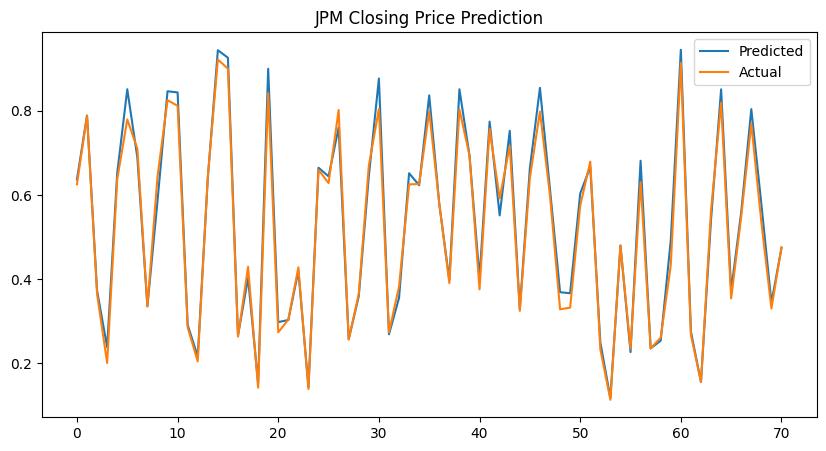

In [ ]:
model.eval()
predictions, actuals = [], []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        pred = model(X_batch).cpu().numpy()
        predictions.extend(pred)
        actuals.extend(y_batch.numpy())

predictions = np.array(predictions).squeeze()
actuals = np.array(actuals).squeeze()

scaled_jpm = scaled_data[:, 0].reshape(-1, 1)
scaler_jpm = MinMaxScaler()
scaler_jpm.fit(scaled_jpm)

pred_real = scaler_jpm.inverse_transform(predictions.reshape(-1, 1))
actual_real = scaler_jpm.inverse_transform(actuals.reshape(-1, 1))

plt.figure(figsize=(10, 5))
plt.plot(pred_real, label='Predicted')
plt.plot(actual_real, label='Actual')
plt.legend()
plt.title('JPM Closing Price Prediction')
plt.show()

#evaluate trained model

In [ ]:

tick = ['/JPM', '/MSFT', '/SNY', '/VZ', '/WBD']
dfs = []

for ticker in tick:
    df = pd.read_csv(f'{ticker}.csv')[['Date', 'close']]
    df.rename(columns={'close': f'{ticker}_close'}, inplace=True)
    dfs.append(df)

# Merge all on Date
data = dfs[0]
for df in dfs[1:]:
    data = pd.merge(data, df, on='Date')

data['Date'] = pd.to_datetime(data['Date'])
data.sort_values('Date', inplace=True)
data.dropna(inplace=True)
data.reset_index(drop=True, inplace=True)

features = data.drop(columns=['Date']).values


In [ ]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(features)

SEQ_LEN = 20  # history steps
PRED_LEN = 1  # 1-step ahead prediction

def create_sequences(data, seq_len, pred_len):
    X, y = [], []
    for i in range(len(data) - seq_len - pred_len + 1):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len:i+seq_len+pred_len])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled, SEQ_LEN, PRED_LEN)
y = y.squeeze(axis=1)  # shape: (samples, 5)


In [ ]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = StockDataset(X_tensor, y_tensor)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)


In [ ]:
class MultiStockTransformer(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dropout=0.1, output_dim=5):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(d_model, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(1, 0, 2)  # [seq_len, batch, dim]
        encoded = self.transformer(x)
        out = self.decoder(encoded[-1])  # Use last token output
        return out


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiStockTransformer(input_dim=5, output_dim=5).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

EPOCHS = 30

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.5f}")


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1, Loss: 0.24662
Epoch 2, Loss: 0.08477
Epoch 3, Loss: 0.03555
Epoch 4, Loss: 0.03328
Epoch 5, Loss: 0.02337
Epoch 6, Loss: 0.02212
Epoch 7, Loss: 0.01860
Epoch 8, Loss: 0.01631
Epoch 9, Loss: 0.01565
Epoch 10, Loss: 0.01481
Epoch 11, Loss: 0.01419
Epoch 12, Loss: 0.01222
Epoch 13, Loss: 0.01306
Epoch 14, Loss: 0.01282
Epoch 15, Loss: 0.01145
Epoch 16, Loss: 0.01124
Epoch 17, Loss: 0.01095
Epoch 18, Loss: 0.01090
Epoch 19, Loss: 0.01050
Epoch 20, Loss: 0.01072
Epoch 21, Loss: 0.00990
Epoch 22, Loss: 0.00980
Epoch 23, Loss: 0.01004
Epoch 24, Loss: 0.00997
Epoch 25, Loss: 0.00941
Epoch 26, Loss: 0.00969
Epoch 27, Loss: 0.00913
Epoch 28, Loss: 0.00906
Epoch 29, Loss: 0.00900
Epoch 30, Loss: 0.00852


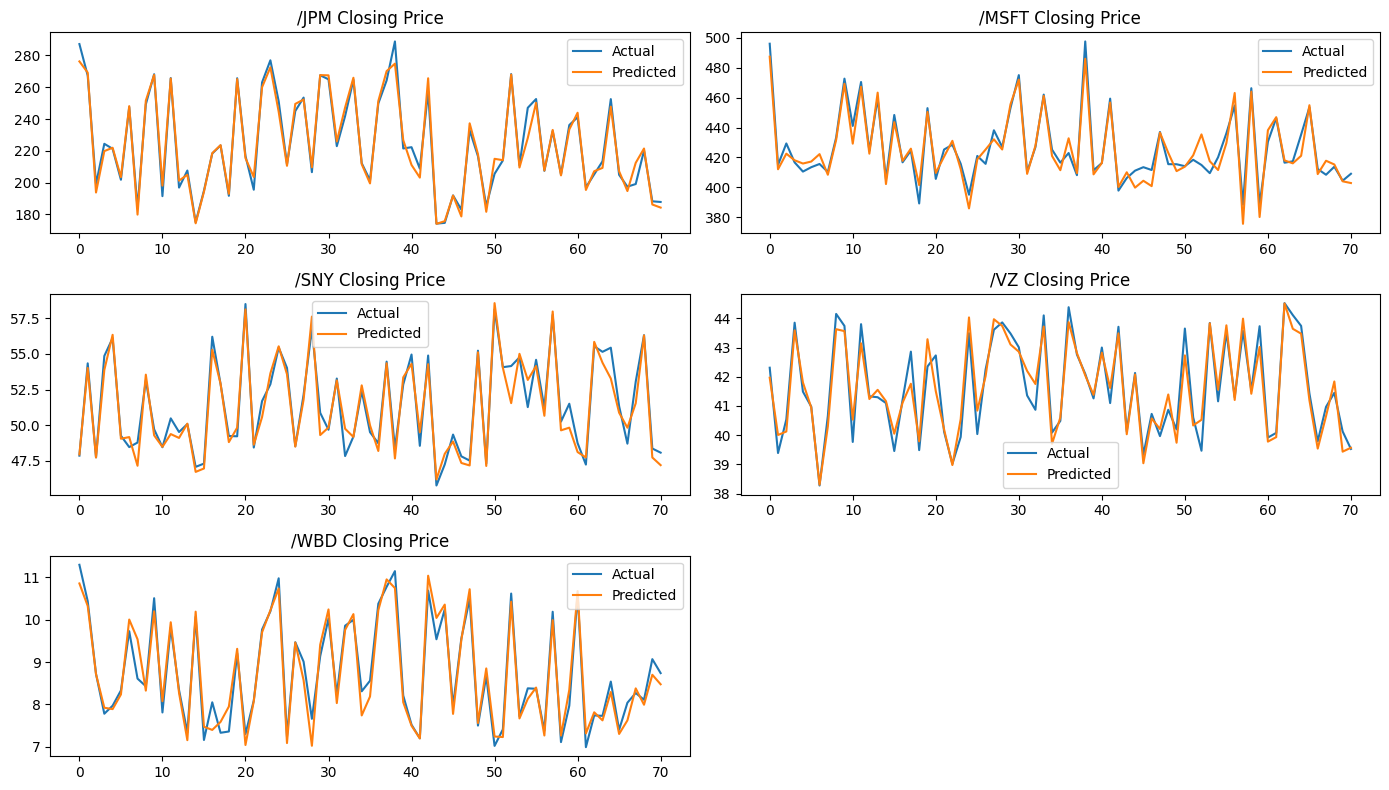

In [ ]:
model.eval()
preds, actuals = [], []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        output = model(X_batch).cpu().numpy()
        preds.append(output)
        actuals.append(y_batch.numpy())

preds = np.concatenate(preds)
actuals = np.concatenate(actuals)

# Inverse scale
preds_inv = scaler.inverse_transform(preds)
actuals_inv = scaler.inverse_transform(actuals)

# Plot for each stock
plt.figure(figsize=(14, 8))
for i, ticker in enumerate(tick):
    plt.subplot(3, 2, i+1)
    plt.plot(actuals_inv[:, i], label='Actual')
    plt.plot(preds_inv[:, i], label='Predicted')
    plt.title(f'{ticker} Closing Price')
    plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
#next 5 days
model.eval()


recent_sequence = torch.tensor(scaled[-SEQ_LEN:], dtype=torch.float32).unsqueeze(0).to(device)  # shape: [1, 20, 5]

future_predictions = []

with torch.no_grad():
    for _ in range(5):  # Predict next 5 days
        out = model(recent_sequence).squeeze(0)  # shape: [5]
        future_predictions.append(out.cpu().numpy())


        next_input = out.unsqueeze(0).unsqueeze(0).to(device)  # [1, 1, 5]
        recent_sequence = torch.cat([recent_sequence[:, 1:, :], next_input], dim=1)  # keep SEQ_LEN length


future_predictions = np.array(future_predictions)  # [5, 5]
future_real = scaler.inverse_transform(future_predictions)

# results
import datetime

last_date = data['Date'].iloc[-1]
next_dates = [last_date + datetime.timedelta(days=i+1) for i in range(5)]

forecast_df = pd.DataFrame(future_real, columns=[f'{t}_predicted' for t in tick])
forecast_df.insert(0, 'Date', next_dates)
print(forecast_df)


                 Date  /JPM_predicted  /MSFT_predicted  /SNY_predicted  \
0 2025-06-28 04:00:00      275.372375       486.621796       47.638401   
1 2025-06-29 04:00:00      271.405212       481.431641       47.600330   
2 2025-06-30 04:00:00      270.050171       478.315948       47.614750   
3 2025-07-01 04:00:00      269.602600       476.337738       47.640110   
4 2025-07-02 04:00:00      269.479828       474.983673       47.663219   

   /VZ_predicted  /WBD_predicted  
0      42.062096       10.982384  
1      41.906353       10.869644  
2      41.778469       10.833124  
3      41.657131       10.823938  
4      41.539997       10.821639  


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from google.colab import files

uploaded = files.upload()


Saving JPM_with_price_diff.csv to JPM_with_price_diff.csv
Saving msft_sentiment_features_full.csv to msft_sentiment_features_full.csv
Saving MSFT_with_price_diff.csv to MSFT_with_price_diff.csv
Saving sny_sentiment_features_full.csv to sny_sentiment_features_full.csv
Saving SNY_with_price_diff.csv to SNY_with_price_diff.csv
Saving v_sentiment_features_full.csv to v_sentiment_features_full.csv
Saving vz_sentiment_features_full.csv to vz_sentiment_features_full.csv
Saving VZ_with_price_diff.csv to VZ_with_price_diff.csv
Saving wbd_sentiment_features_full.csv to wbd_sentiment_features_full.csv
Saving WBD_with_price_diff.csv to WBD_with_price_diff.csv


In [10]:
import pandas as pd


jpm_df = pd.read_csv('JPM_with_price_diff.csv')
msft_df = pd.read_csv('MSFT_with_price_diff.csv')
sny_df = pd.read_csv('SNY_with_price_diff.csv')
vz_df = pd.read_csv('VZ_with_price_diff.csv')
wbd_df = pd.read_csv('WBD_with_price_diff.csv')

msft_sent_df = pd.read_csv('msft_sentiment_features_full.csv')
sny_sent_df = pd.read_csv('sny_sentiment_features_full.csv')
jpm_sent_df = pd.read_csv('v_sentiment_features_full.csv')  # verify if this is correct
vz_sent_df = pd.read_csv('vz_sentiment_features_full.csv')
wbd_sent_df = pd.read_csv('wbd_sentiment_features_full.csv')

In [5]:
from google.colab import files

uploaded = files.upload()


Saving msft_q1_2024_transcript.csv to msft_q1_2024_transcript.csv
Saving msft_q1_2025_transcript.csv to msft_q1_2025_transcript.csv
Saving msft_q2_2024_transcript.csv to msft_q2_2024_transcript.csv
Saving msft_q2_2025_transcript.csv to msft_q2_2025_transcript.csv
Saving msft_q3_2024_transcript.csv to msft_q3_2024_transcript.csv
Saving msft_q4_2024_transcript.csv to msft_q4_2024_transcript.csv
Saving sny_q1_2024_transcript.csv to sny_q1_2024_transcript.csv
Saving sny_q1_2025_transcript.csv to sny_q1_2025_transcript.csv
Saving sny_q2_2024_transcript.csv to sny_q2_2024_transcript.csv
Saving sny_q2_2025_transcript.csv to sny_q2_2025_transcript.csv
Saving sny_q3_2024_transcript.csv to sny_q3_2024_transcript.csv
Saving sny_q4_2024_transcript.csv to sny_q4_2024_transcript.csv
Saving v_q1_2024_transcript.csv to v_q1_2024_transcript.csv
Saving v_q1_2025_transcript.csv to v_q1_2025_transcript.csv
Saving v_q2_2024_transcript.csv to v_q2_2024_transcript.csv
Saving v_q2_2025_transcript.csv to v_q2_

In [6]:
import pandas as pd


transcripts = {}


for filename in uploaded.keys():
    if filename.endswith('_transcript.csv'):
        df = pd.read_csv(filename)
        transcripts[filename] = df


print("Loaded Transcript Files:")
for name in transcripts:
    print(f"{name}: {transcripts[name].shape[0]} rows")


Loaded Transcript Files:
msft_q1_2024_transcript.csv: 51 rows
msft_q1_2025_transcript.csv: 34 rows
msft_q2_2024_transcript.csv: 51 rows
msft_q2_2025_transcript.csv: 50 rows
msft_q3_2024_transcript.csv: 51 rows
msft_q4_2024_transcript.csv: 51 rows
sny_q1_2024_transcript.csv: 75 rows
sny_q1_2025_transcript.csv: 17 rows
sny_q2_2024_transcript.csv: 85 rows
sny_q2_2025_transcript.csv: 29 rows
sny_q3_2024_transcript.csv: 48 rows
sny_q4_2024_transcript.csv: 98 rows
v_q1_2024_transcript.csv: 59 rows
v_q1_2025_transcript.csv: 76 rows
v_q2_2024_transcript.csv: 74 rows
v_q2_2025_transcript.csv: 60 rows
v_q3_2024_transcript.csv: 68 rows
v_q4_2024_transcript.csv: 67 rows
vz_q1_2024_transcript.csv: 74 rows
vz_q1_2025_transcript.csv: 58 rows
vz_q2_2024_transcript.csv: 83 rows
vz_q2_2025_transcript.csv: 81 rows
vz_q3_2024_transcript.csv: 24 rows
vz_q4_2024_transcript.csv: 65 rows
wbd_q1_2024_transcript.csv: 41 rows
wbd_q1_2025_transcript.csv: 45 rows
wbd_q2_2024_transcript.csv: 50 rows
wbd_q3_2024_tra

In [12]:

sentiment_files = {
    'MSFT': 'msft_sentiment_features_full.csv',
    'SNY': 'sny_sentiment_features_full.csv',
    'VZ': 'vz_sentiment_features_full.csv',
    'WBD': 'wbd_sentiment_features_full.csv',
    'JPM': 'v_sentiment_features_full.csv'  # assume v = jpm
}

price_diff_files = {
    'MSFT': 'MSFT_with_price_diff.csv',
    'SNY': 'SNY_with_price_diff.csv',
    'VZ': 'VZ_with_price_diff.csv',
    'WBD': 'WBD_with_price_diff.csv',
    'JPM': 'JPM_with_price_diff.csv'
}


In [13]:

def load_and_merge(symbol):
    sent_df = pd.read_csv(sentiment_files[symbol])
    price_df = pd.read_csv(price_diff_files[symbol])


    sent_df['date'] = pd.to_datetime(sent_df['date'])
    price_df['Date'] = pd.to_datetime(price_df['Date'])

    merged = pd.merge(sent_df, price_df, left_on='date', right_on='Date')
    merged['symbol'] = symbol
    return merged


all_data = pd.concat([load_and_merge(sym) for sym in sentiment_files.keys()], ignore_index=True)


/tmp/ipython-input-2406719980.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  price_df['Date'] = pd.to_datetime(price_df['Date'])


In [14]:

quantiles = all_data['Closing_price_change'].quantile([0.1, 0.9])
low_thresh = quantiles[0.1]
high_thresh = quantiles[0.9]

def classify(change):
    if change >= high_thresh:
        return 1  # Positive
    elif change <= low_thresh:
        return -1  # Negative
    else:
        return 0  # Neutral

all_data['label'] = all_data['Closing_price_change'].apply(classify)


In [18]:
print("All data shape:", all_data.shape)
print("Feature columns found in all_data:", [col for col in all_data.columns])


All data shape: (0, 105)
Feature columns found in all_data: ['date', 'sentiment_mean', 'sentiment_std', 'sentiment_count', 'sentiment_min', 'sentiment_max', 'relevance_mean', 'relevance_sum', 'overall_sentiment_mean', 'overall_sentiment_std', 'source_count', 'article_count', 'sentiment_polarity', 'sentiment_momentum', 'sentiment_volatility', 'weighted_sentiment', 'sentiment_ma_3d', 'sentiment_std_3d', 'article_count_ma_3d', 'relevance_ma_3d', 'sentiment_trend_3d', 'sentiment_ma_7d', 'sentiment_std_7d', 'article_count_ma_7d', 'relevance_ma_7d', 'sentiment_trend_7d', 'sentiment_ma_14d', 'sentiment_std_14d', 'article_count_ma_14d', 'relevance_ma_14d', 'sentiment_trend_14d', 'sentiment_ma_30d', 'sentiment_std_30d', 'article_count_ma_30d', 'relevance_ma_30d', 'sentiment_trend_30d', 'sentiment_rsi', 'sentiment_macd', 'sentiment_macd_signal', 'sentiment_bb_upper', 'sentiment_bb_lower', 'sentiment_rate_of_change', 'sentiment_acceleration', 'Blockchain_relevance_score', 'Earnings_relevance_scor

In [19]:

def load_and_merge(symbol):
    sent_df = pd.read_csv(sentiment_files[symbol])
    price_df = pd.read_csv(price_diff_files[symbol])

    sent_df['date'] = pd.to_datetime(sent_df['date']).dt.date
    price_df['Date'] = pd.to_datetime(price_df['Date']).dt.date


    merged = pd.merge(sent_df, price_df, left_on='date', right_on='Date', how='inner')
    merged['symbol'] = symbol
    return merged


In [20]:
all_data = pd.concat([load_and_merge(sym) for sym in sentiment_files.keys()], ignore_index=True)
print("Merged all_data shape:", all_data.shape)


Merged all_data shape: (1824, 104)


/tmp/ipython-input-161569935.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  price_df['Date'] = pd.to_datetime(price_df['Date']).dt.date


In [23]:
# Only run this once!
quantiles = all_data['Closing_price_change'].quantile([0.1, 0.9])
low_thresh = quantiles[0.1]
high_thresh = quantiles[0.9]

def classify(change):
    if change >= high_thresh:
        return 1
    elif change <= low_thresh:
        return -1
    else:
        return 0

all_data['label'] = all_data['Closing_price_change'].apply(classify)


In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


feature_cols = ['sentiment_mean', 'sentiment_std', 'sentiment_count',
                'sentiment_min', 'sentiment_max', 'relevance_mean',
                'relevance_sum', 'overall_sentiment_mean',
                'overall_sentiment_std', 'source_count']

X = all_data[feature_cols]
y = all_data['label']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)


In [28]:
# multinomial logistic regression model
clf = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
clf.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

In [31]:
clf = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)


In [32]:

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Classification Report:
               precision    recall  f1-score   support

Negative (-1)       0.08      0.19      0.11        36
  Neutral (0)       0.87      0.53      0.66       292
 Positive (1)       0.18      0.49      0.26        37

     accuracy                           0.49       365
    macro avg       0.37      0.40      0.34       365
 weighted avg       0.72      0.49      0.56       365



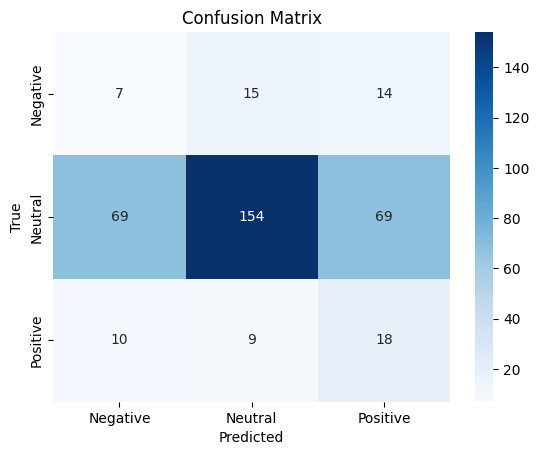

In [33]:
from sklearn.metrics import classification_report, confusion_matrix


print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative (-1)", "Neutral (0)", "Positive (1)"]))

# Plot confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [39]:
# sort chronologically
all_data_sorted = all_data.sort_values(by='date')


X = all_data_sorted[feature_cols]
y = all_data_sorted['label']
X_scaled = scaler.fit_transform(X)


In [40]:
#Using TimeSeriesSplit for Accuracy.

In [41]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np


In [42]:
tscv = TimeSeriesSplit(n_splits=5)



Fold 1


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


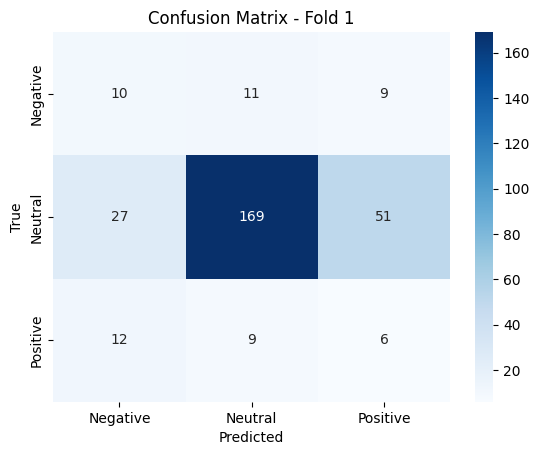


Fold 2


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


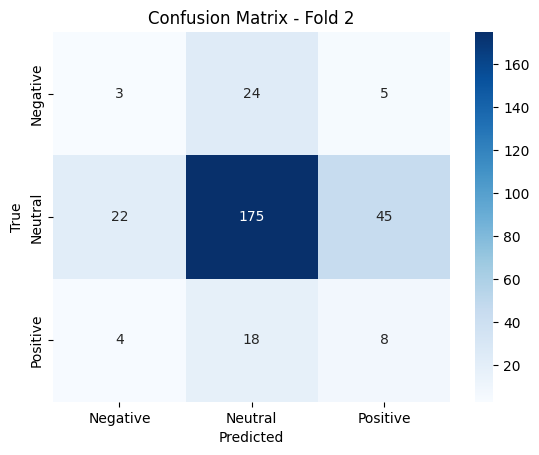


Fold 3


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


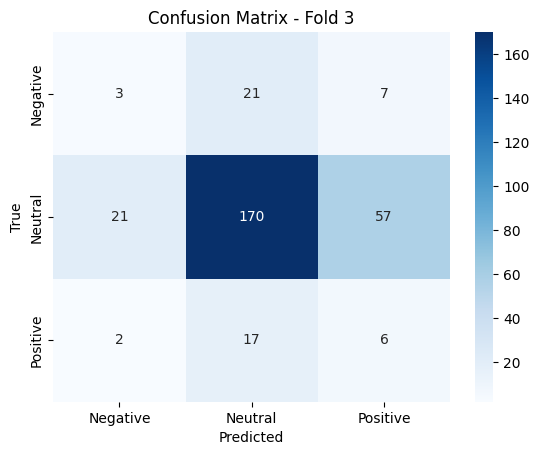


Fold 4


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


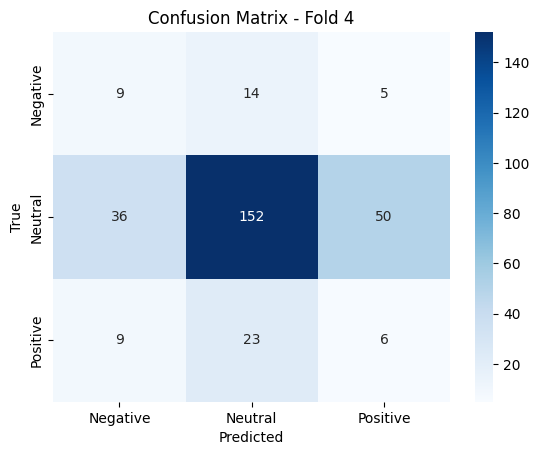


Fold 5


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


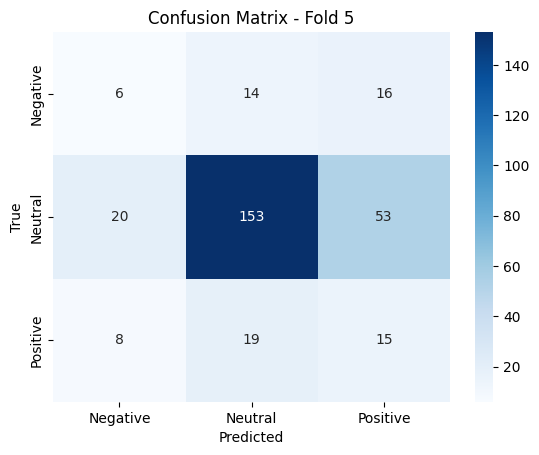

In [43]:
all_reports = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_scaled)):
    print(f"\nFold {fold + 1}")

    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    clf = LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)


    report = classification_report(y_test, y_pred, output_dict=True)
    all_reports.append(report)

    conf_mat = confusion_matrix(y_test, y_pred)
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Negative", "Neutral", "Positive"],
                yticklabels=["Negative", "Neutral", "Positive"])
    plt.title(f"Confusion Matrix - Fold {fold + 1}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


In [44]:
# Average F1-score across all folds
avg_f1 = np.mean([fold['weighted avg']['f1-score'] for fold in all_reports])
print(f"\nAverage Weighted F1 Score Across Folds: {avg_f1:.4f}")



Average Weighted F1 Score Across Folds: 0.6258


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


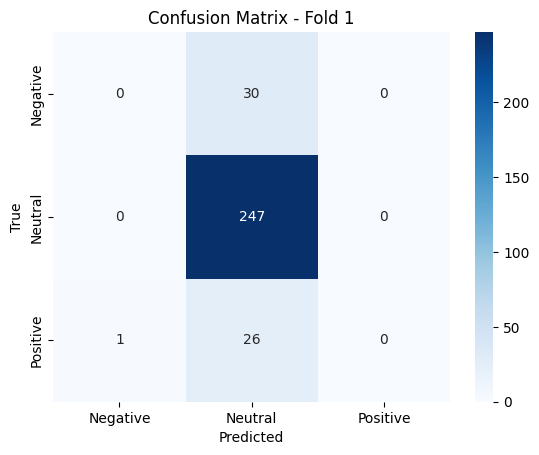

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


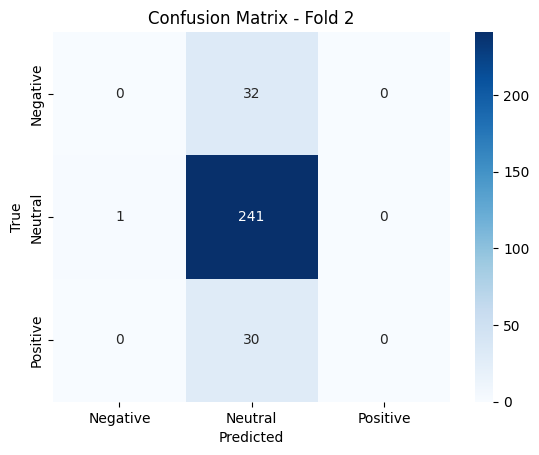

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


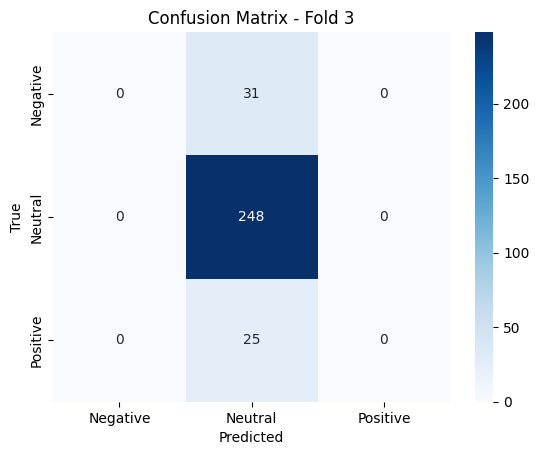

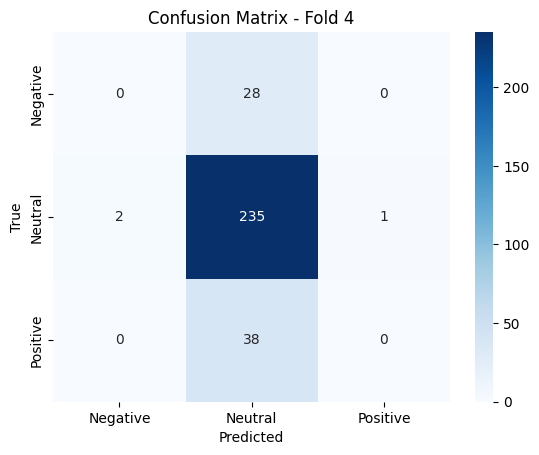

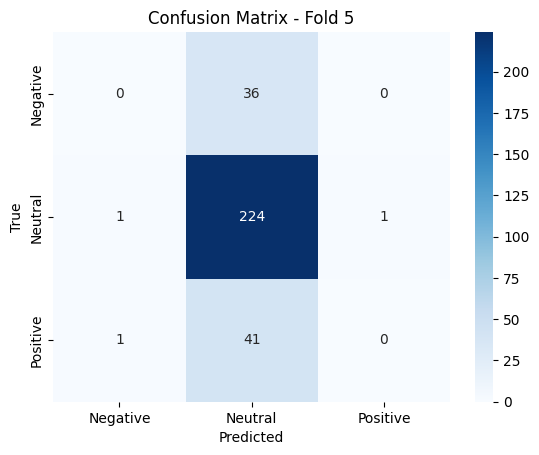


Average Weighted F1 Score Across Folds: 0.6963


In [45]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


all_data_sorted = all_data.sort_values(by='date')


feature_cols = [
    'sentiment_mean', 'sentiment_std', 'sentiment_count',
    'sentiment_min', 'sentiment_max', 'relevance_mean',
    'relevance_sum', 'overall_sentiment_mean',
    'overall_sentiment_std', 'source_count'
]
X = all_data_sorted[feature_cols]
y = all_data_sorted['label']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
all_reports = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_scaled)):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


    clf = RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    )
    clf.fit(X_train, y_train)


    y_pred = clf.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    all_reports.append(report)


    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Neutral', 'Positive'],
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(f'Confusion Matrix - Fold {fold+1}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# Average F1 Score
avg_f1 = np.mean([fold['weighted avg']['f1-score'] for fold in all_reports])
print(f"\nAverage Weighted F1 Score Across Folds: {avg_f1:.4f}")
